# Lightgbm

## Imports

In [342]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.set_up import set_up
import src.utility.util as utl


## Datasets

We have four datasets we want to train our models on:
* **A1**: A1 contains samples with and without review scores / sentiment features. Each sample has an indicator whether it had reviews or not. Missing values are filled with 0. (A1 is the dataset we obtain from 02_preprocessing.ipynb).
* **A2**: A2 contains only samples with all review scores and sentiment features.
* **B1**: B1 contains only samples without review scores. The review scores and sentiment columns are dropped after preprocessing.  
* **B2**: B2 contains samples with and without review scores. The review scores and sentiment columns are dropped after preprocessing.

All the other features are processed the same way in each set and the test set is the same for each set. See src/data/loading.py for more details.

The point is that not every listing has gotten reviews, especially new ones. Therefore we want to try models that do not rely on reviews.

We create all our datasets, so we can load and use them for training (see **src/set_up.py**).

In [343]:
# Preprocess the data and save it in .parquet files
load = False
if load:
    set_up()

## A1

### Load

In [344]:
# Load training and test sets
X_train_A1 = pd.read_parquet('../data/processed/A1/X_train.parquet', engine='pyarrow')
y_train_A1 = pd.read_parquet('../data/processed/A1/y_train.parquet', engine='pyarrow')
X_test_A1 = pd.read_parquet('../data/processed/A1/X_test.parquet', engine='pyarrow')
y_test_A1 = pd.read_parquet('../data/processed/A1/y_test.parquet', engine='pyarrow')

### Initialise Lightgbm regressor

In [345]:
# lightgbm
lgbm_A1 = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    random_state=42,
    n_jobs=-1
)

### Train

In [346]:
lgbm_A1.fit(X_train_A1, y_train_A1['price'])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004531 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7840
[LightGBM] [Info] Number of data points in the train set: 12170, number of used features: 78
[LightGBM] [Info] Start training from score 4.824662


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Test

In [347]:
predictions_A1_log = lgbm_A1.predict(X_test_A1)
prices_A1_log = y_test_A1['price'].to_list()

predictions_A1 = np.expm1(predictions_A1_log)
prices_A1 = np.expm1(prices_A1_log)

In [348]:
utl.show_errors(prices_A1_log, predictions_A1_log)

===== TEST SET =====
RMSE: €95.88
MAE:  €40.43
Median AE:  €18.88
R²:   0.6845

R² (log-scale): 0.8131


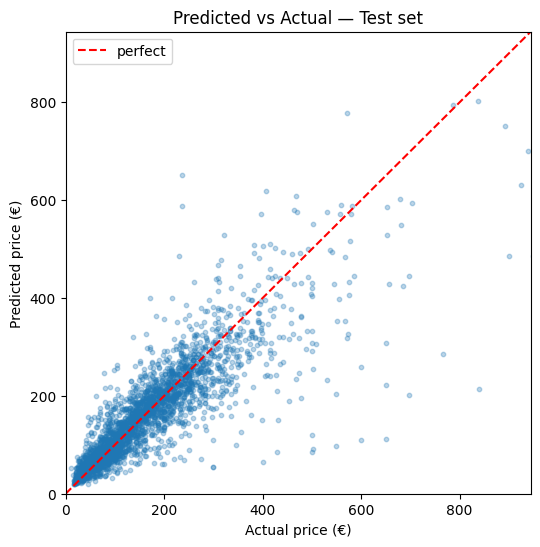

In [349]:
utl.plot_true_versus_predicted(prices_A1, predictions_A1)

## A2

### Load

In [350]:
# Load training and test sets
X_train_A2 = pd.read_parquet('../data/processed/A2/X_train.parquet', engine='pyarrow')
y_train_A2 = pd.read_parquet('../data/processed/A2/y_train.parquet', engine='pyarrow')
X_test_A2 = pd.read_parquet('../data/processed/A2/X_test.parquet', engine='pyarrow')
y_test_A2 = pd.read_parquet('../data/processed/A2/y_test.parquet', engine='pyarrow')

### Initialise Lightgbm regressor

In [351]:
# lightgbm
lgbm_A2 = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    random_state=42,
    n_jobs=-1
)

### Train

In [352]:
lgbm_A2.fit(X_train_A2, y_train_A2['price'])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004276 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7803
[LightGBM] [Info] Number of data points in the train set: 9404, number of used features: 77
[LightGBM] [Info] Start training from score 4.885922


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Test

In [353]:
predictions_A2_log = lgbm_A2.predict(X_test_A2)
prices_A2_log = y_test_A2['price'].to_list()

predictions_A2 = np.expm1(predictions_A2_log)
prices_A2 = np.expm1(prices_A2_log)

In [354]:
utl.show_errors(prices_A2_log, predictions_A2_log)

===== TEST SET =====
RMSE: €103.33
MAE:  €43.08
Median AE:  €20.17
R²:   0.6336

R² (log-scale): 0.7759


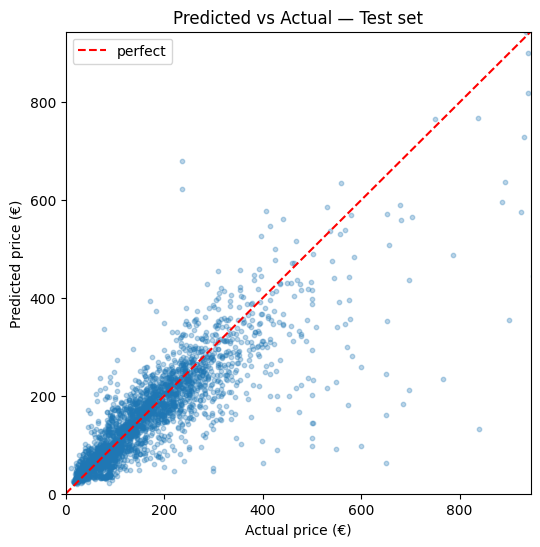

In [355]:
utl.plot_true_versus_predicted(prices_A2, predictions_A2)

## B1

### Load

In [356]:
# Load training and test sets
X_train_B1 = pd.read_parquet('../data/processed/B1/X_train.parquet', engine='pyarrow')
y_train_B1 = pd.read_parquet('../data/processed/B1/y_train.parquet', engine='pyarrow')
X_test_B1 = pd.read_parquet('../data/processed/B1/X_test.parquet', engine='pyarrow')
y_test_B1 = pd.read_parquet('../data/processed/B1/y_test.parquet', engine='pyarrow')

### Initialise Lightgbm regressor

In [357]:
# lightgbm
lgbm_B1 = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    random_state=42,
    n_jobs=-1
)

### Train

In [358]:
lgbm_B1.fit(X_train_B1, y_train_B1['price'])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000943 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3004
[LightGBM] [Info] Number of data points in the train set: 2766, number of used features: 53
[LightGBM] [Info] Start training from score 4.616384


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Test

In [359]:
predictions_B1_log = lgbm_B1.predict(X_test_B1)
prices_B1_log = y_test_B1['price'].to_list()

predictions_B1 = np.expm1(predictions_B1_log)
prices_B1 = np.expm1(prices_B1_log)

In [360]:
utl.show_errors(prices_B1_log, predictions_B1_log)

===== TEST SET =====
RMSE: €117.79
MAE:  €59.61
Median AE:  €27.84
R²:   0.5239

R² (log-scale): 0.6805


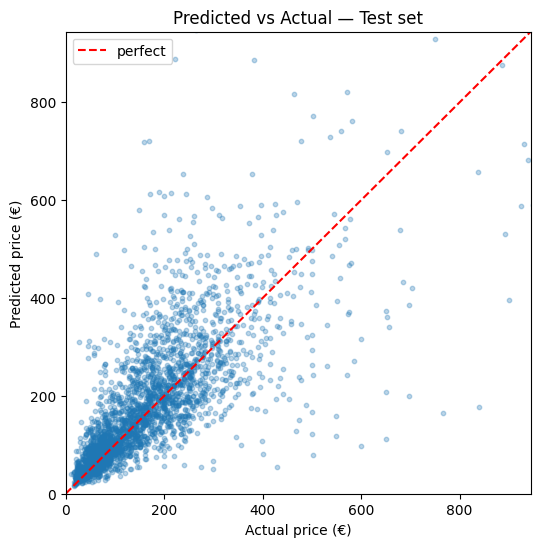

In [361]:
utl.plot_true_versus_predicted(prices_B1, predictions_B1)

## B2

### Load

In [362]:
# Load training and test sets
X_train_B2 = pd.read_parquet('../data/processed/B2/X_train.parquet', engine='pyarrow')
y_train_B2 = pd.read_parquet('../data/processed/B2/y_train.parquet', engine='pyarrow')
X_test_B2 = pd.read_parquet('../data/processed/B2/X_test.parquet', engine='pyarrow')
y_test_B2 = pd.read_parquet('../data/processed/B2/y_test.parquet', engine='pyarrow')

### Initialise Lightgbm regressor

In [363]:
# lightgbm
lgbm_B2 = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=-1,
    random_state=42,
    n_jobs=-1
)

### Train

In [364]:
lgbm_B2.fit(X_train_B2, y_train_B2['price'])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003692 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3623
[LightGBM] [Info] Number of data points in the train set: 12170, number of used features: 57
[LightGBM] [Info] Start training from score 4.824662


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Test

In [365]:
predictions_B2_log = lgbm_B2.predict(X_test_B2)
prices_B2_log = y_test_B2['price'].to_list()

predictions_B2 = np.expm1(predictions_B2_log)
prices_B2 = np.expm1(prices_B2_log)

In [366]:
utl.show_errors(prices_B2_log, predictions_B2_log)

===== TEST SET =====
RMSE: €94.80
MAE:  €39.35
Median AE:  €18.60
R²:   0.6916

R² (log-scale): 0.8153


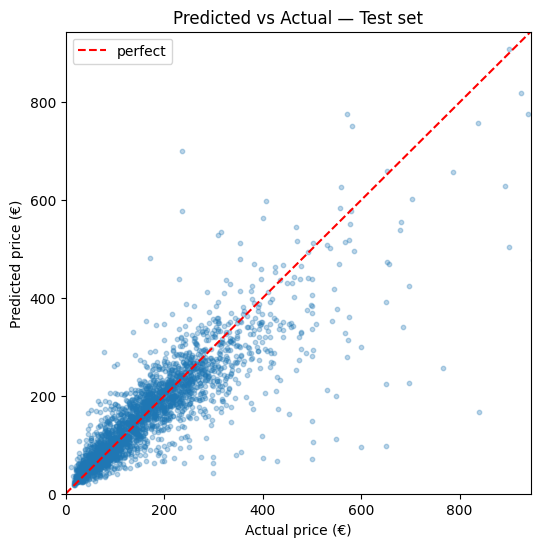

In [367]:
utl.plot_true_versus_predicted(prices_B2, predictions_B2)